In [7]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm
import tensorflow
from tensorflow import keras
import time

In [8]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [9]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [10]:
X_train=torch.from_numpy(X_train).float()
X_test=torch.from_numpy(X_test).float()
y_train=torch.from_numpy(y_train).long()
y_test = torch.from_numpy(y_test).long()
X_test=X_test.unsqueeze(1)
X_train=X_train.unsqueeze(1)

In [11]:
class CNN_network(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=torch.nn.Conv2d(1,32,3)
        self.conv2=torch.nn.Conv2d(32,64,3)
        self.conv3=torch.nn.Conv2d(64,128,3)
        self.pool=torch.nn.MaxPool2d(2,2)
        self.relu=torch.nn.ReLU()
        self.drop1=torch.nn.Dropout(0.25)
        self.drop2=torch.nn.Dropout(0.5)
        self.flatten=torch.nn.Flatten()
        self.linear1=torch.nn.Linear(128,64)
        self.linear2=torch.nn.Linear(64,10)
    def forward(self,x):
        x=self.conv1(x)
        x=self.relu(x)
        x=self.pool(x)
        x=self.drop1(x)
        
        x=self.conv2(x)
        x=self.relu(x)
        x=self.pool(x)
        x=self.drop1(x)
        
        x=self.conv3(x)
        x=self.relu(x)
        x=self.pool(x)
        x=self.drop1(x)
        
        x=self.flatten(x)
        
        x=self.linear1(x)
        x=self.relu(x)
        x=self.drop2(x)
        
        x=self.linear2(x)
        return x

In [12]:
model = CNN_network().to(device)  
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
loss_fn=torch.nn.CrossEntropyLoss()
history=[]
batch_size=64
start = time.time()
epochs=10
for epoc in tqdm(range(epochs)):
    for i in range(0,len(X_train),batch_size):
        X_batch=X_train[i:i+batch_size].to(device)
        Y_batch=y_train[i:i+batch_size].to(device)
        optimizer.zero_grad()
        pred=model(X_batch)
        loss=loss_fn(pred,Y_batch)
        loss.backward()
        history.append(loss.item())
        optimizer.step()
end = time.time()

print(f"Training Time: {end - start:.2f} seconds")

100%|██████████| 10/10 [00:28<00:00,  2.80s/it]

Training Time: 28.04 seconds


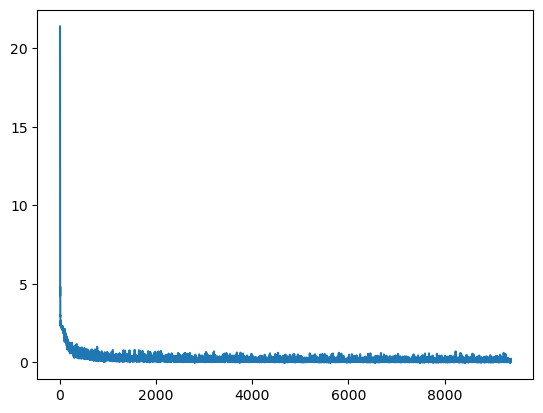

In [13]:
plt.plot(history)
plt.show()

In [14]:
model.eval()             #TRAIN SET ACCURACY

with torch.no_grad():
    logits = model(X_train.to(device))       #PREDIICTION
predictions = torch.argmax(logits, dim=1)
correct = (predictions ==y_train.to(device)).sum().item()
accuracy = correct / len(y_train)
print(predictions,y_train)
print(f"Accuracy: {accuracy * 100:.2f}%")

tensor([5, 0, 4,  ..., 5, 6, 8], device='cuda:0') tensor([5, 0, 4,  ..., 5, 6, 8])
Accuracy: 99.06%


In [15]:
model.eval()                #TEST SET ACCURACY

with torch.no_grad():
    logits = model(X_test.to(device))       #PREDIICTION
predictions = torch.argmax(logits, dim=1)
correct = (predictions == y_test.to(device)).sum().item()
accuracy = correct / len(y_test)
print(predictions,y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

tensor([7, 2, 1,  ..., 4, 5, 6], device='cuda:0') tensor([7, 2, 1,  ..., 4, 5, 6])
Accuracy: 98.68%
